In [44]:
import numpy as np
import pandas as pd 
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)


In [45]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = malignant, 1 = benign

print('Dataset shape:', X.shape)
print('Class distribution:')
print(y.value_counts().rename({0: 'Malignant', 1: 'Benign'}))

# Train/test split — stratify to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('\nTrain size:', X_train.shape, '| Test size:', X_test.shape)

Dataset shape: (569, 30)
Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64

Train size: (455, 30) | Test size: (114, 30)


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, GridSearchCV
from sklearn.svm import SVC

### Decision Tree

In [54]:
dt_pipe = Pipeline([
    ('scaler', StandardScaler()),
    # ('model', DecisionTreeClassifier(random_state=42))
    ('estimator', KNeighborsClassifier())
])

param_grid = {
    # 'model__max_depth': np.arange(0, 40),
    'estimator__n_neighbors': np.arange(1, 15, 2)
}

grid_search = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid
    # n_iter=10,
    # random_state=42, 
)

random_search.fit(X_train, y_train)

y_pred = random_search.predict(X_test)


In [55]:
results = []
results.append({
        'Model': 'KNN',
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
    })

print(results)
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

[{'Model': 'KNN', 'Accuracy': 0.9737, 'Precision': 0.96, 'Recall': 1.0, 'F1 Score': 0.9796}]
              precision    recall  f1-score   support

   Malignant       1.00      0.93      0.96        42
      Benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



[[39  3]
 [ 0 72]]


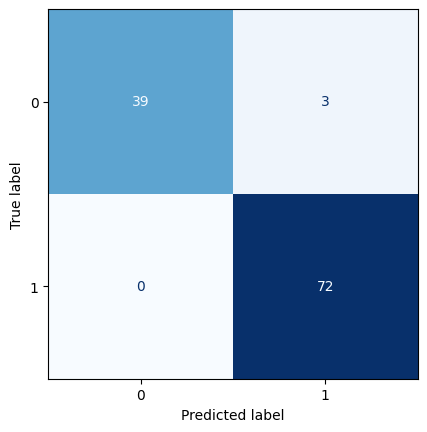

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay

)
y_pred = random_search.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(colorbar=False, cmap='Blues')
print(cm)